# Coefficients with Fixed Lambdas

Have simulations with lambda = 0.01, 0.1, 1, 10, 100
For each, construct betas and plot. 
Do large lambda values push coefficients to zero?

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

dim = 3 # replacing X.shape[1]

In [4]:
lbda_range = [0.01, 0.1, 1, 10, 100]
all_results = pd.DataFrame()

for lbda in lbda_range:

    # open results file
    filepath = f'/Users/liviafingerson/Desktop/GitHub/IEMS399-GP/MCMC/lambda_testing/50walkers/emcee_lbda{lbda}_result.json'    
    with open(filepath) as f:
        data = json.load(f)

    result_tab = pd.DataFrame(data['posterior']['content'])
    lbda2 = lbda**2

    # calculate tau_sq from samples
    for i in range(dim):
        zetas = result_tab[f"zeta{i}"].values
        tau_sqs = (2 * zetas) / lbda2
        result_tab[f"tau_sq{i}"] = tau_sqs

    # calculate beta from samples
    for i in range(dim):
        nus = result_tab[f"nu{i}"].values
        result_tab["sigma_noise"] = 1 / result_tab["inv_sigma_noise"].values
        tau_sqs = result_tab[f"tau_sq{i}"].values
        betas = nus * np.sqrt(tau_sqs) * result_tab["sigma_noise"].values
        result_tab[f"beta{i}"] = betas

    result_tab["lambda"] = lbda

    drop_cols = [f"zeta{i}" for i in range(dim)] + ["inv_sigma_noise", "inv_sigma_gp"] + [f"nu{i}" for i in range(dim)]
    clean_tab = result_tab.drop(columns=drop_cols) # drop unneeded columns
    clean_tab = clean_tab.reindex(sorted(clean_tab.columns), axis=1) # sort columns alphabetically

    all_results = pd.concat([all_results, clean_tab], ignore_index=True)

In [17]:
# all_results.head()
all_results[all_results['lambda'] == 1].head()

,beta0,beta1,beta2,ell0,ell1,ell2,lambda,log_likelihood,log_prior,sigma_noise,tau_sq0,tau_sq1,tau_sq2
8000,-4.808013,-3.105263,-4.742173,0.000643,0.3456,1.476671,1.0,-109520.566896,-41.788645,1.040709,4.891631,8.105463,10.687518
8001,-4.808013,-3.105263,-4.742173,0.000643,0.3456,1.476671,1.0,-7002.431321,-12.901287,1.040709,4.891631,8.105463,10.687518
8002,-4.808013,-3.105263,-4.742173,0.000643,0.3456,1.476671,1.0,-35210.161426,-14.856455,1.040709,4.891631,8.105463,10.687518
8003,-4.808013,-3.105263,-4.742173,0.000643,0.3456,1.476671,1.0,-184117.775195,-11.936506,1.040709,4.891631,8.105463,10.687518
8004,-4.808013,-3.105263,-4.742173,0.000643,0.3456,1.476671,1.0,-14977.976801,-11.896260,1.040709,4.891631,8.105463,10.687518


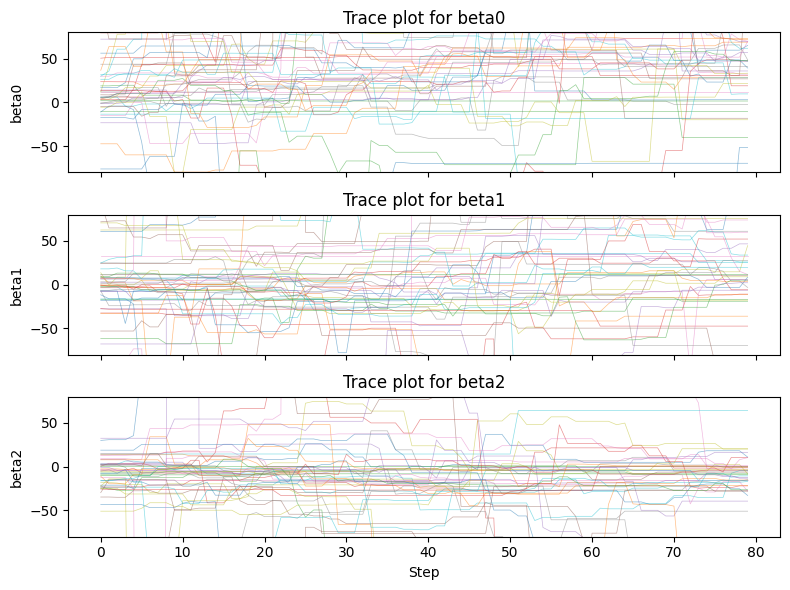

In [14]:
# plot trace plots for an individual lambda

clean_tab = all_results[all_results["lambda"] == 0.1]  # choose one lambda value to plot

fig, axes = plt.subplots(dim, 1, figsize=(8, 2*dim), sharex=True)

for i in range(dim):
    ax = axes[i]
    traces = clean_tab[f"beta{i}"].to_numpy().reshape(50, 80).T
    ax.plot(traces, alpha=0.5, linewidth=0.5)  # matplotlib will plot each walker as a line
    ax.set_ylim([-80, 80])
    ax.set_title(f"Trace plot for beta{i}")
    ax.set_ylabel(f"beta{i}")

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

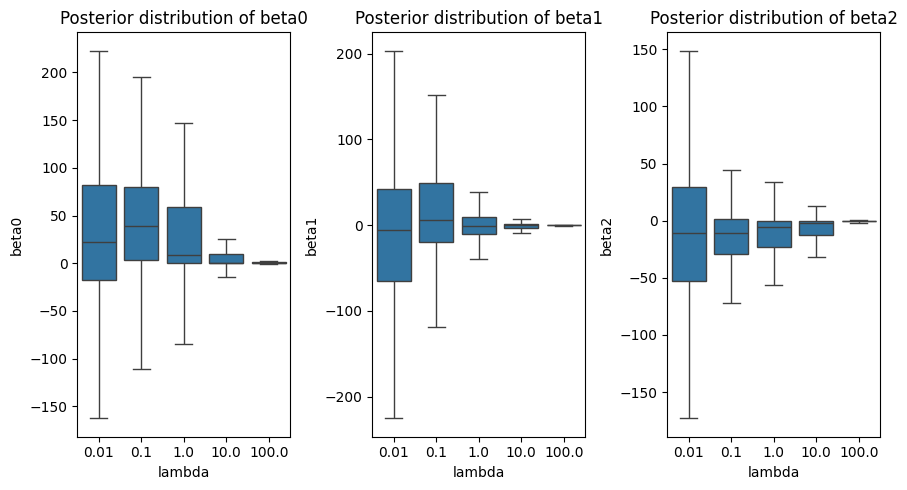

In [21]:
fig, axes = plt.subplots(1, dim, figsize=(3*dim, 5))

for i in range(dim):
    sns.boxplot(
        data=all_results,
        x="lambda",
        y=f"beta{i}",
        ax=axes[i],
        showfliers=False, # false doesn't show outliers
    )
    axes[i].set_title(f"Posterior distribution of beta{i}")
    axes[i].set_xlabel("lambda")
    axes[i].set_ylabel(f"beta{i}")

plt.tight_layout()
plt.show()
